# Olist E-Commerce Exploratory Data Analysis

## Introduction

This notebook performs exploratory data analysis on the cleaned Olist e-commerce datasets. The objective is to examine data distributions, identify meaningful patterns, analyze customer and order behavior, and prepare insights for the feature engineering and machine learning stages of the project.

## Table of Contents

1. Importing Libraries
2. Loading the Cleaned Datasets
3. Dataset Overview
4. Numerical Feature Analysis
5. Categorical Feature Analysis
6. Customer Analysis
7. Order Analysis
8. Business Insights
9. Correlation Analysis
10. Conclusion

## 1. Importing Libraries

The required Python libraries are imported for data manipulation, numerical operations, and data visualization.

In [176]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

## 2. Loading the Cleaned Datasets

The cleaned datasets generated during the data preprocessing stage are loaded from the processed data directory. These datasets will be used throughout the exploratory data analysis.

In [177]:
PROCESSED_DATA_PATH = "../data/processed"

In [178]:
customers = pd.read_csv(
    os.path.join(PROCESSED_DATA_PATH, "customers_clean.csv")
)

geolocation = pd.read_csv(
    os.path.join(PROCESSED_DATA_PATH, "geolocation_clean.csv")
)

order_items = pd.read_csv(
    os.path.join(PROCESSED_DATA_PATH, "order_items_clean.csv")
)

order_payments = pd.read_csv(
    os.path.join(PROCESSED_DATA_PATH, "order_payments_clean.csv")
)

order_reviews = pd.read_csv(
    os.path.join(PROCESSED_DATA_PATH, "order_reviews_clean.csv")
)

orders = pd.read_csv(
    os.path.join(PROCESSED_DATA_PATH, "orders_clean.csv")
)

products = pd.read_csv(
    os.path.join(PROCESSED_DATA_PATH, "products_clean.csv")
)

sellers = pd.read_csv(
    os.path.join(PROCESSED_DATA_PATH, "sellers_clean.csv")
)

category_translation = pd.read_csv(
    os.path.join(
        PROCESSED_DATA_PATH,
        "category_translation_clean.csv"
    )
)

In [179]:
datasets = {
    "Customers": customers,
    "Geolocation": geolocation,
    "Order Items": order_items,
    "Order Payments": order_payments,
    "Order Reviews": order_reviews,
    "Orders": orders,
    "Products": products,
    "Sellers": sellers,
    "Category Translation": category_translation
}

In [180]:
for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows, {df.shape[1]} columns")

Customers: 99,441 rows, 5 columns
Geolocation: 738,332 rows, 5 columns
Order Items: 112,650 rows, 7 columns
Order Payments: 103,886 rows, 5 columns
Order Reviews: 99,224 rows, 7 columns
Orders: 99,441 rows, 8 columns
Products: 32,951 rows, 9 columns
Sellers: 3,095 rows, 4 columns
Category Translation: 71 rows, 2 columns


## 3. Dataset Overview

This section summarizes the dimensions of the cleaned datasets used in the exploratory data analysis. The number of rows and columns in each dataset is examined to understand the scale and structure of the available data.

In [181]:
dataset_overview = []

for name, df in datasets.items():
    dataset_overview.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1]
    })

dataset_overview_df = pd.DataFrame(dataset_overview)

dataset_overview_df

,Dataset,Rows,Columns
0,Customers,99441,5
1,Geolocation,738332,5
2,Order Items,112650,7
3,Order Payments,103886,5
4,Order Reviews,99224,7
5,Orders,99441,8
6,Products,32951,9
7,Sellers,3095,4
8,Category Translation,71,2


In [182]:
dataset_overview_df = dataset_overview_df.sort_values(
    by="Rows",
    ascending=False
).reset_index(drop=True)

dataset_overview_df

,Dataset,Rows,Columns
0,Geolocation,738332,5
1,Order Items,112650,7
2,Order Payments,103886,5
3,Customers,99441,5
4,Orders,99441,8
5,Order Reviews,99224,7
6,Products,32951,9
7,Sellers,3095,4
8,Category Translation,71,2


### Observations

The datasets vary significantly in size because they represent different components of the e-commerce system.

The Geolocation dataset contains the highest number of records. Transactional datasets such as Order Items, Order Payments, Orders, and Order Reviews also contain a large number of observations and will form the main basis of the exploratory analysis.

Supporting datasets such as Products, Sellers, Customers, and Category Translation will be used to enrich the analysis by combining related information across multiple datasets and enabling feature comparison.

## 4. Numerical Feature Analysis

This section explores the distributions of important numerical variables in the Olist e-commerce dataset. Understanding these variables helps identify data characteristics, potential outliers, and overall purchasing behavior.

### 4.1 Price Distribution

In [183]:
order_items["price"].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

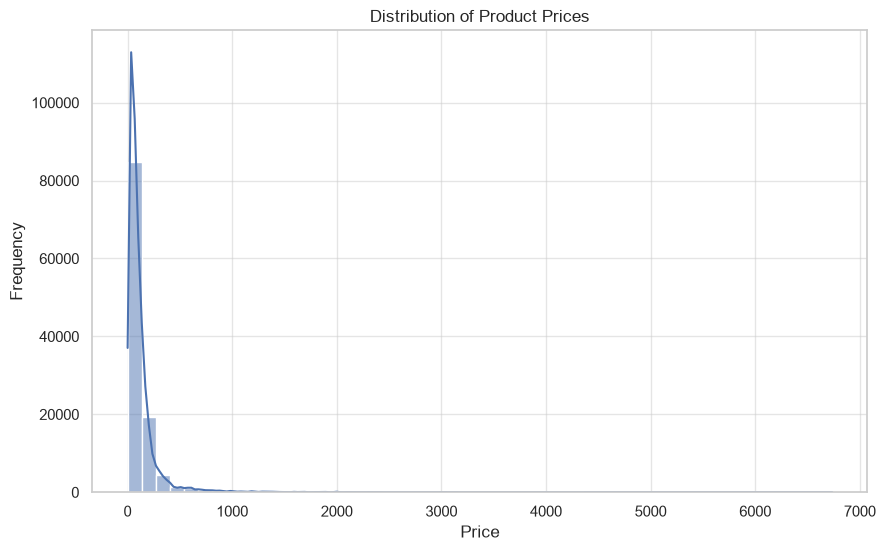

In [184]:
plt.figure(figsize=(10, 6))

sns.histplot(
    order_items["price"],
    bins=50,
    kde=True
)

plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

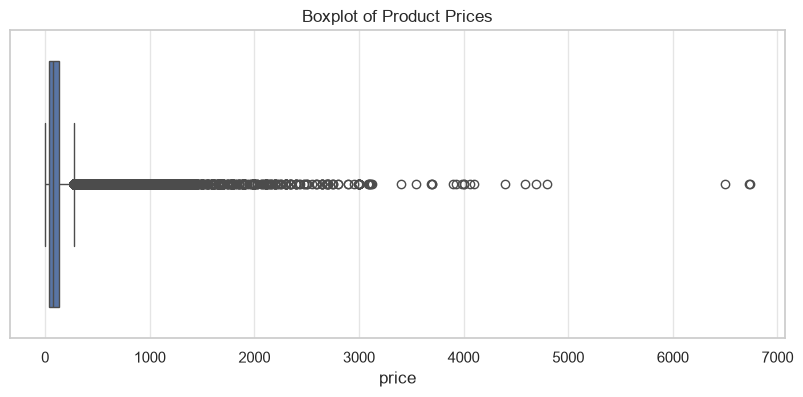

In [185]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=order_items["price"]
)

plt.title("Boxplot of Product Prices")

plt.show()

### 4.2 Freight Value Distribution

The freight value represents the shipping cost associated with each order item. Analyzing its distribution helps identify typical shipping costs and detect unusually high freight charges.

In [186]:
order_items["freight_value"].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

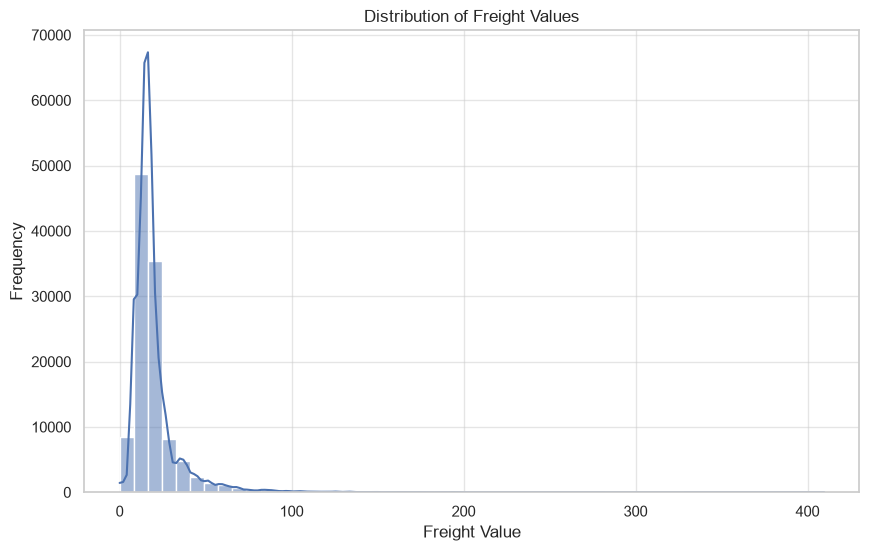

In [187]:
plt.figure(figsize=(10, 6))

sns.histplot(
    order_items["freight_value"],
    bins=50,
    kde=True
)

plt.title("Distribution of Freight Values")
plt.xlabel("Freight Value")
plt.ylabel("Frequency")

plt.show()

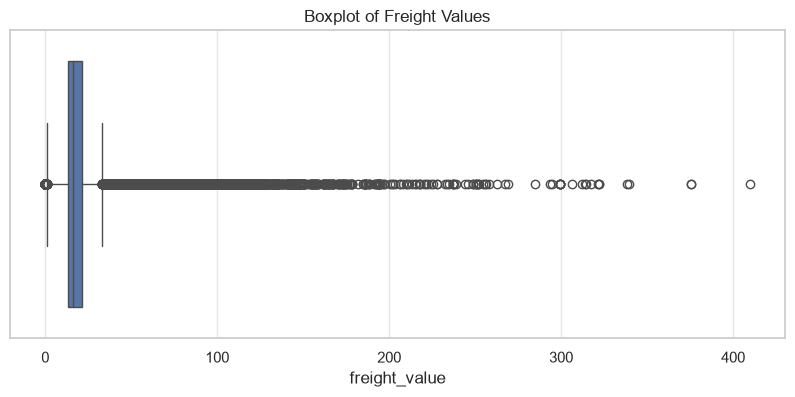

In [188]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=order_items["freight_value"]
)

plt.title("Boxplot of Freight Values")

plt.show()

#### Observations

The freight value distribution is positively skewed, with the majority of shipping costs concentrated at relatively low values.

A limited number of orders have substantially higher freight charges, which appear as outliers in the boxplot. These observations may correspond to heavy, oversized, or long-distance shipments.

### 4.3 Review Score Distribution

Customer review scores provide valuable insights into customer satisfaction. This section examines the distribution of review ratings to understand the overall quality of customer experiences.

In [189]:
order_reviews["review_score"].describe()

count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

In [190]:
order_reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

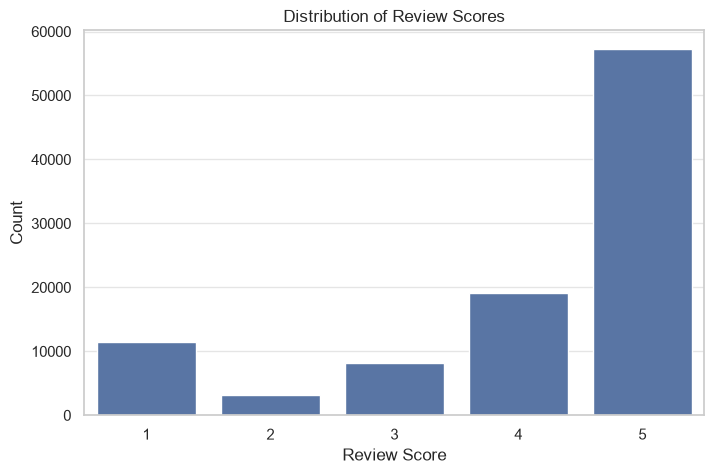

In [191]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=order_reviews,
    x="review_score"
)

plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")

plt.show()

#### Observations

The review score distribution is heavily concentrated at the highest rating, indicating that most customers reported positive shopping experiences.

Lower review scores occur much less frequently, suggesting that dissatisfied customers represent a relatively small proportion of the overall customer base. This imbalance should be considered in future predictive modeling tasks involving customer satisfaction.

### 4.4 Product Weight Distribution

Product weight is an important characteristic that directly influences shipping costs and logistics operations. This section analyzes the distribution of product weights to identify common weight ranges and potential extreme values.

In [192]:
products["product_weight_g"].describe()

count    32949.000000
mean      2276.472488
std       4282.038731
min          0.000000
25%        300.000000
50%        700.000000
75%       1900.000000
max      40425.000000
Name: product_weight_g, dtype: float64

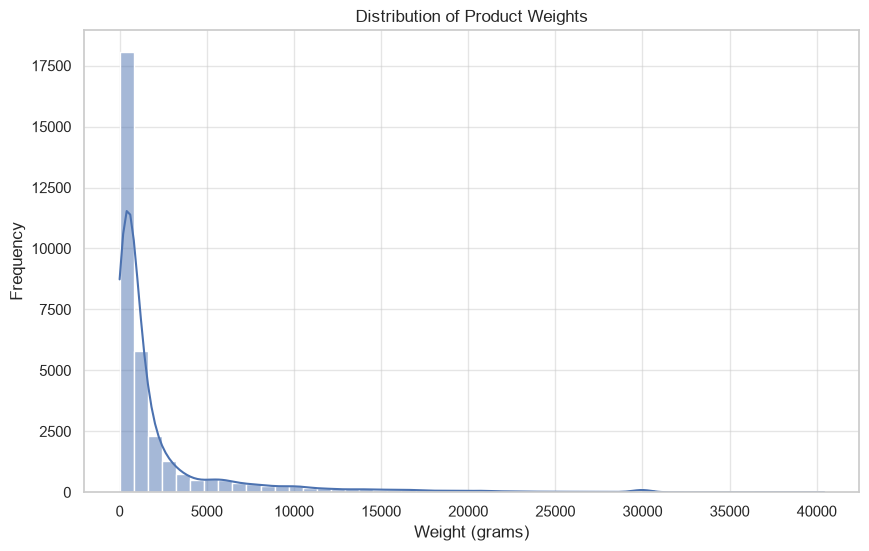

In [193]:
plt.figure(figsize=(10, 6))

sns.histplot(
    products["product_weight_g"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Product Weights")
plt.xlabel("Weight (grams)")
plt.ylabel("Frequency")

plt.show()

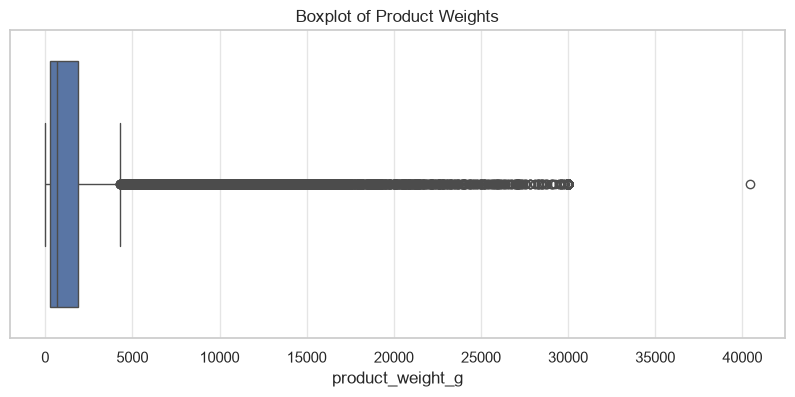

In [194]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=products["product_weight_g"].dropna()
)

plt.title("Boxplot of Product Weights")

plt.show()

#### Observations

The distribution of product weights is positively skewed, with most products having relatively low weights.

Several products exhibit substantially higher weights, appearing as outliers in the boxplot. These heavier products may contribute to increased freight costs and should be considered during subsequent analyses involving logistics or shipping expenses.

## 5. Categorical Feature Analysis

This section examines the distributions of important categorical variables in the dataset. Understanding these variables provides valuable insights into customer behavior, order fulfillment, payment preferences, and product categories.

### 5.1 Order Status Distribution

Order status reflects the progress and completion of customer orders. Analyzing this variable helps evaluate operational performance and identify potential delivery or cancellation issues.

In [195]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [196]:
(
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

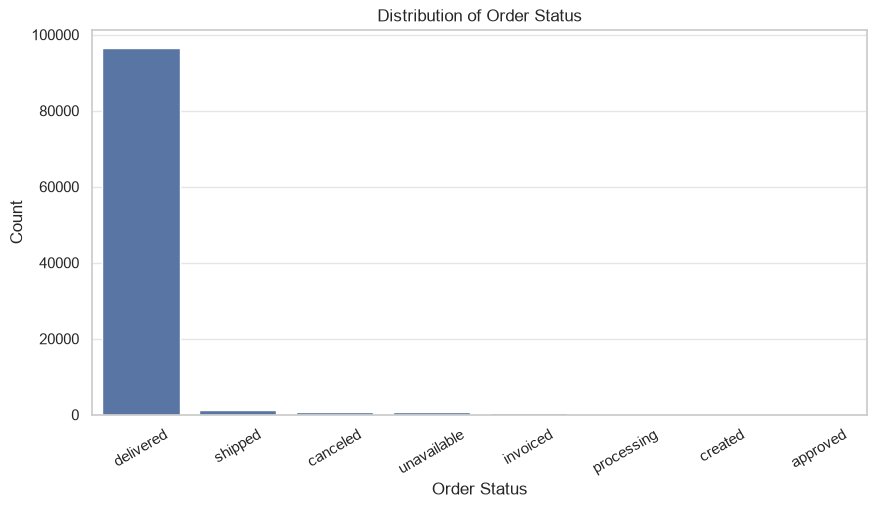

In [197]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=orders,
    x="order_status",
    order=orders["order_status"].value_counts().index
)

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.show()

#### Observations

Most orders have the status **delivered**, indicating that the order fulfillment process is generally successful.

A relatively small number of orders fall into categories such as **canceled**, **unavailable**, or **processing**, suggesting that unsuccessful transactions represent only a minor portion of the overall order volume.

These results indicate a high overall order completion rate and efficient fulfillment performance within the e-commerce platform.

### 5.2 Payment Type Distribution

Payment type is an important categorical feature that reflects customer purchasing preferences. This section analyzes the frequency of different payment methods used in the e-commerce platform.

In [198]:
payment_counts = (
    order_payments["payment_type"]
    .value_counts()
)

payment_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [199]:
(
    order_payments["payment_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

payment_type
credit_card    73.92
boleto         19.04
voucher         5.56
debit_card      1.47
not_defined     0.00
Name: proportion, dtype: float64

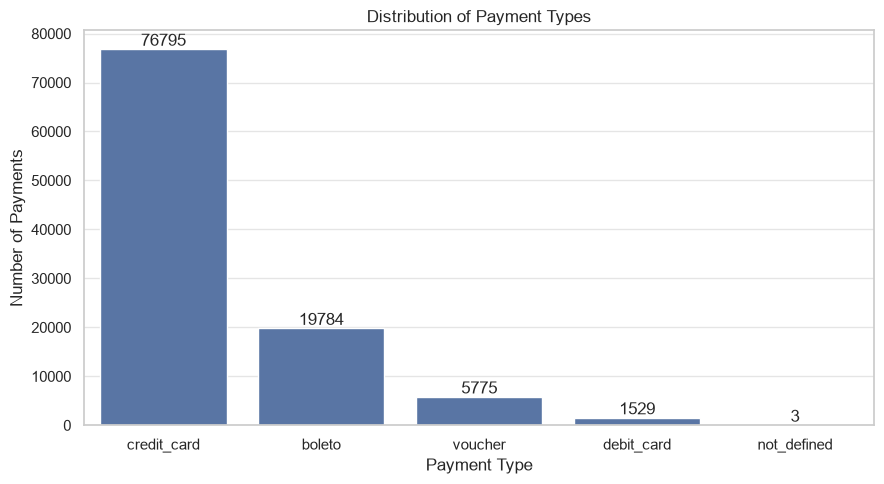

In [200]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Payment Types")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")

plt.tight_layout()
plt.show()

#### Observations

Credit cards are the most frequently used payment method, indicating that customers strongly prefer card-based transactions.

Other payment methods, including boleto, vouchers, and debit cards, are used considerably less often. This distribution highlights the dominance of credit card payments within the platform and suggests that alternative payment methods represent a smaller share of customer transactions.

### 5.3 Top Product Categories

This section identifies the most common product categories available in the Olist e-commerce platform. The Portuguese category names are translated into English to improve readability and interpretation.

In [201]:
products_category = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

products_category.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [202]:
top_categories = (
    products_category["product_category_name_english"]
    .value_counts()
    .head(10)
)

top_categories

product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64

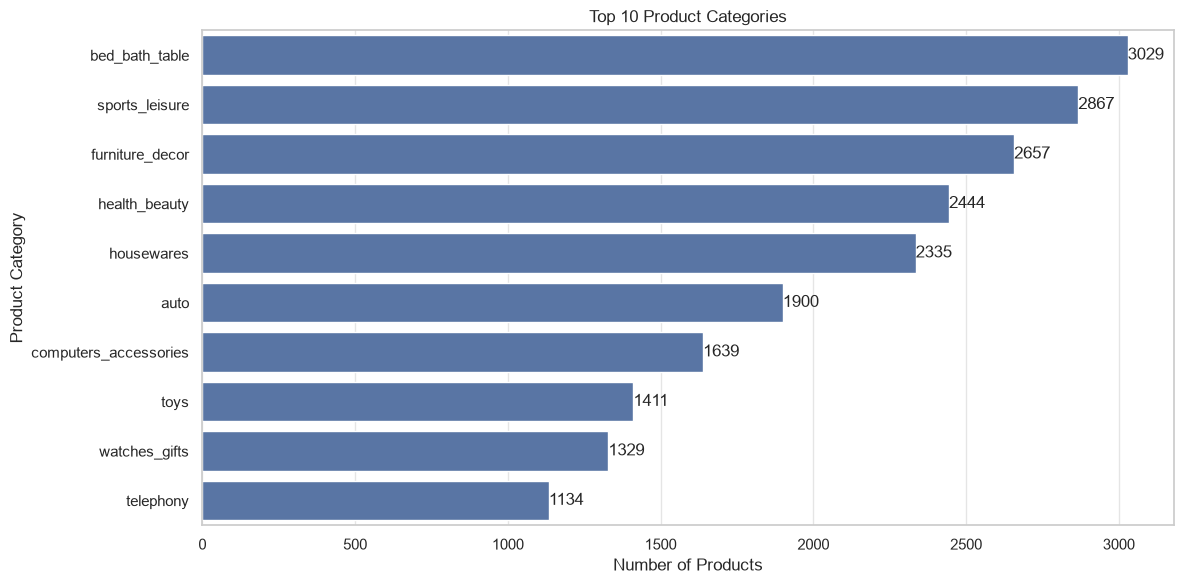

In [203]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Product Categories")
plt.xlabel("Number of Products")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

#### Observations

The dataset contains a diverse range of product categories, with a small number of categories accounting for a substantial proportion of all listed products.

Categories such as **bed_bath_table**, **sports_leisure**, and **health_beauty** appear among the most common product groups, indicating that these product segments play an important role within the Olist marketplace.

Understanding category popularity is valuable for inventory planning, recommendation systems, and customer purchasing behavior analysis.

## 6. Customer Analysis

This section explores customer-related information to better understand customer distribution and purchasing behavior. The analysis focuses on geographical distribution and customer activity across different states.

### 6.1 Customer Distribution by State

Customer locations provide valuable insights into the geographical distribution of the customer base. This analysis identifies the states with the highest number of registered customers.

In [204]:
customer_state_counts = (
    customers["customer_state"]
    .value_counts()
)

customer_state_counts.head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

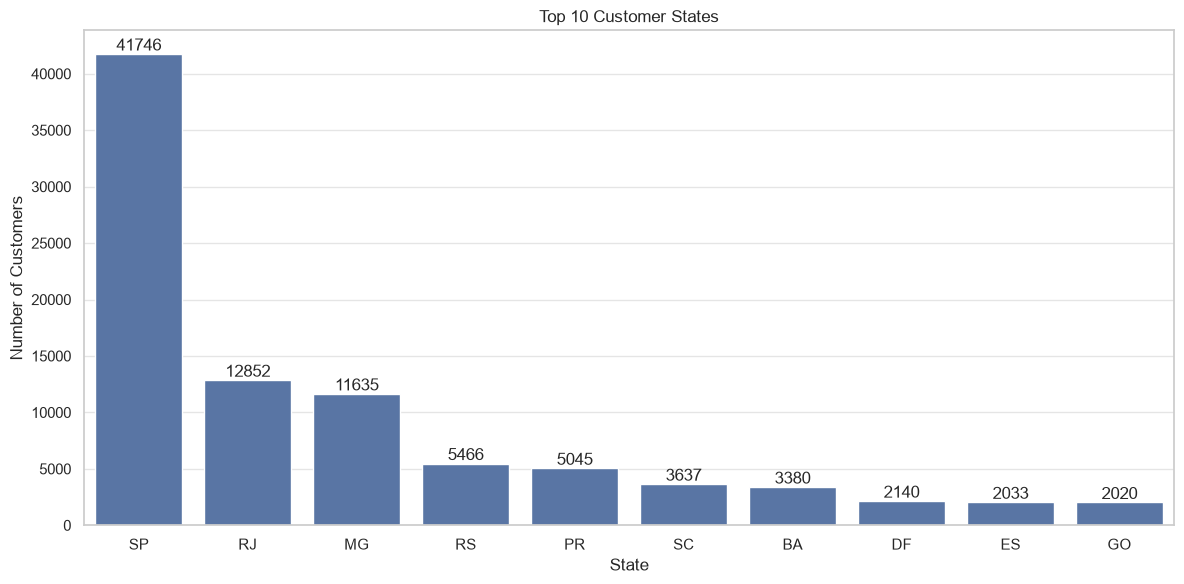

In [205]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=customer_state_counts.head(10).index,
    y=customer_state_counts.head(10).values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Customer States")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

#### Observations

The customer base is concentrated in a limited number of states, indicating that demand is not evenly distributed across the country.

States with the highest customer counts represent the primary markets of the Olist platform and may provide valuable opportunities for targeted marketing campaigns and logistics optimization.

### 6.2 Customer Distribution by City

Customer distribution across cities provides a more detailed geographical perspective. This analysis identifies the cities with the largest customer populations.

In [206]:
customer_city_counts = (
    customers["customer_city"]
    .value_counts()
    .head(10)
)

customer_city_counts

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64

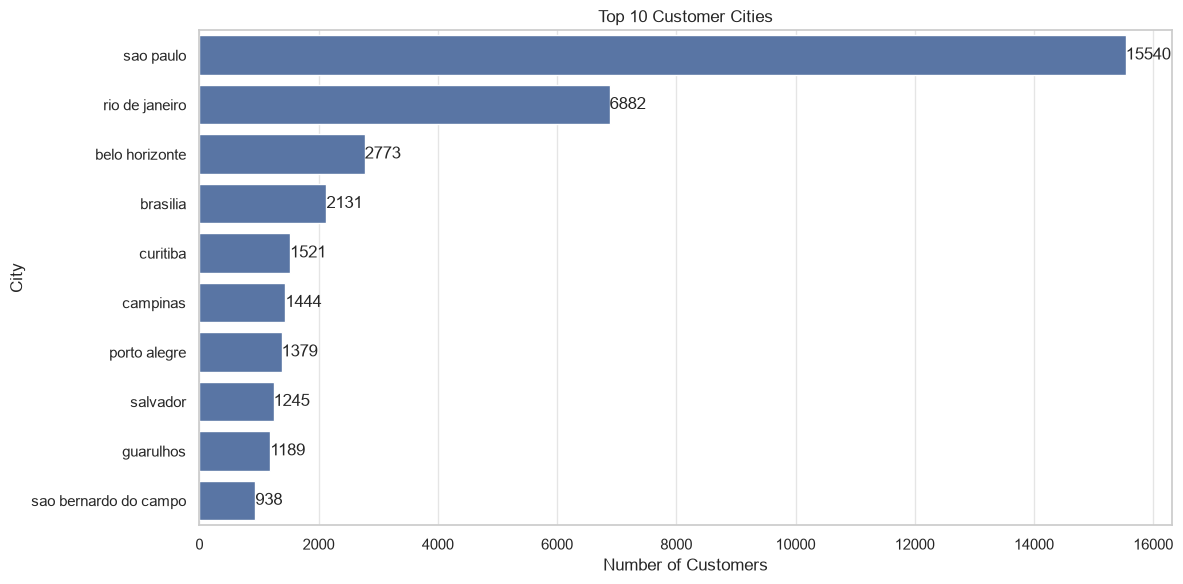

In [207]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=customer_city_counts.values,
    y=customer_city_counts.index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Customer Cities")
plt.xlabel("Number of Customers")
plt.ylabel("City")

plt.tight_layout()
plt.show()

#### Observations

A relatively small number of cities account for a significant share of the customer base.

Large metropolitan areas dominate the customer distribution, reflecting higher population density and stronger e-commerce adoption in urban regions.

### 6.3 Customer Purchase Frequency

Customer purchase frequency measures how many orders each customer has placed on the platform. This analysis helps distinguish between one-time and repeat customers, providing valuable insights into customer loyalty and purchasing behavior.

In [208]:
customer_orders = customers.merge(
    orders,
    on="customer_id",
    how="inner"
)

customer_orders.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15


In [209]:
purchase_frequency = (
    customer_orders
    .groupby("customer_unique_id")
    .size()
    .reset_index(name="number_of_orders")
)

purchase_frequency.head()

,customer_unique_id,number_of_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [210]:
purchase_frequency["number_of_orders"].describe()

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: number_of_orders, dtype: float64

In [211]:
top_customers = (
    purchase_frequency
    .sort_values(
        by="number_of_orders",
        ascending=False
    )
    .head(10)
)

top_customers

,customer_unique_id,number_of_orders
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17
23472,3e43e6105506432c953e165fb2acf44c,9
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7
37797,6469f99c1f9dfae7733b25662e7f1782,7
76082,ca77025e7201e3b30c44b472ff346268,7
27043,47c1a3033b8b77b3ab6e109eb4d5fdf3,6
7175,12f5d6e1cbf93dafd9dcc19095df0b3d,6
37585,63cfc61cee11cbe306bff5857d00bfe4,6
82883,dc813062e0fc23409cd255f7f53c7074,6
83540,de34b16117594161a6a89c50b289d35a,6


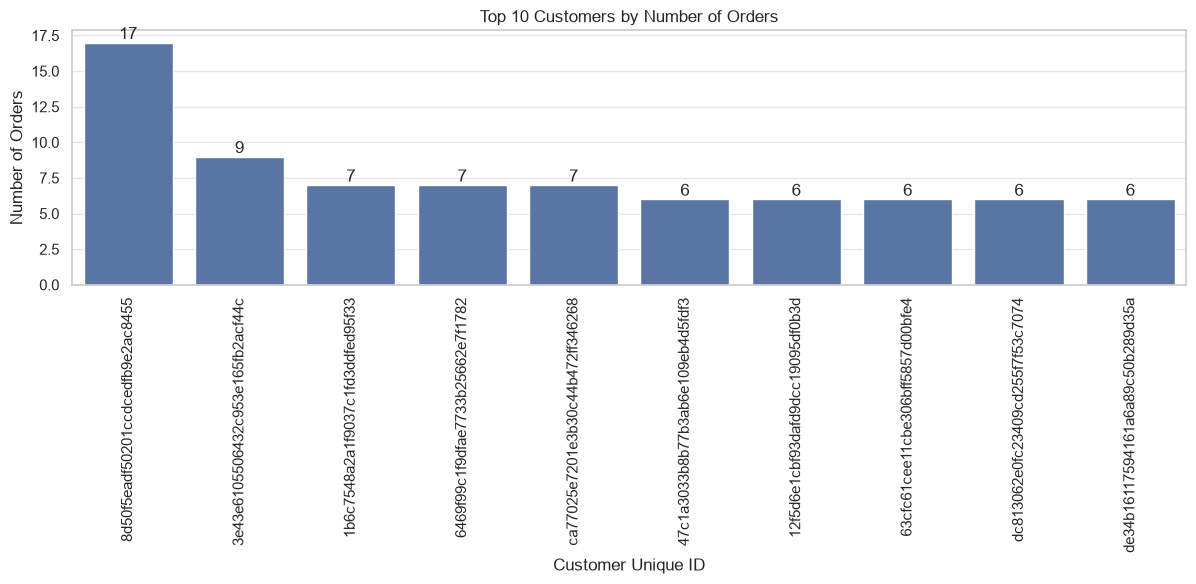

In [212]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=top_customers["customer_unique_id"],
    y=top_customers["number_of_orders"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Customer Unique ID")
plt.ylabel("Number of Orders")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

#### Observations

Most customers place only a small number of orders, indicating that one-time purchases are common within the Olist platform.

A limited number of customers make multiple purchases, representing loyal or highly engaged customers. These customers may be valuable targets for customer retention strategies, personalized recommendations, and loyalty programs.

## 7. Order Analysis

This section examines order-related information to understand purchasing trends, order growth, and delivery performance across the Olist platform.

### 7.1 Orders by Year

Analyzing the number of orders by year provides a high-level overview of the platform's growth over time.

In [213]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["purchase_year"] = (
    orders["order_purchase_timestamp"]
    .dt.year
)

orders_per_year = (
    orders["purchase_year"]
    .value_counts()
    .sort_index()
)

orders_per_year

purchase_year
2016      329
2017    45101
2018    54011
Name: count, dtype: int64

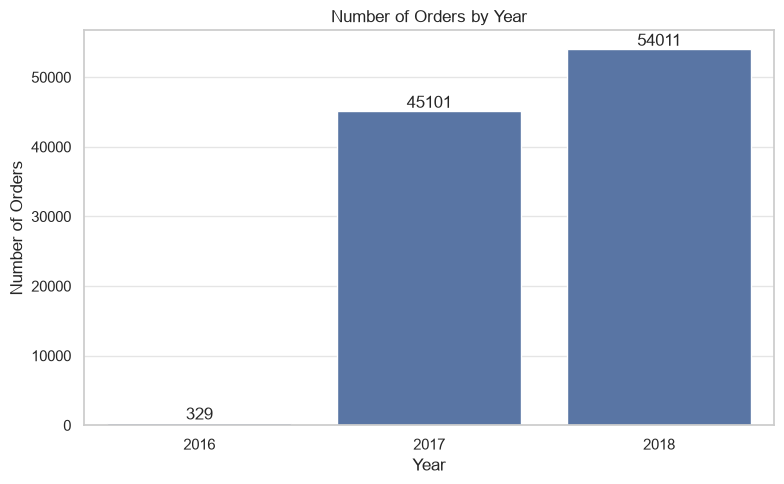

In [214]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=orders_per_year.index.astype(str),
    y=orders_per_year.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Orders by Year")
plt.xlabel("Year")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

#### Observations

The number of orders increased considerably over the observed years, indicating the continuous growth of the Olist marketplace.

This trend suggests an expanding customer base and increasing platform activity over time.

### 7.2 Monthly Order Trend

Monthly order analysis helps identify seasonal purchasing patterns and business growth trends. Understanding these trends can support inventory planning, marketing strategies, and sales forecasting.

In [215]:
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [216]:
monthly_orders = (
    orders["purchase_month"]
    .value_counts()
    .sort_index()
)

monthly_orders

purchase_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Name: count, dtype: int64

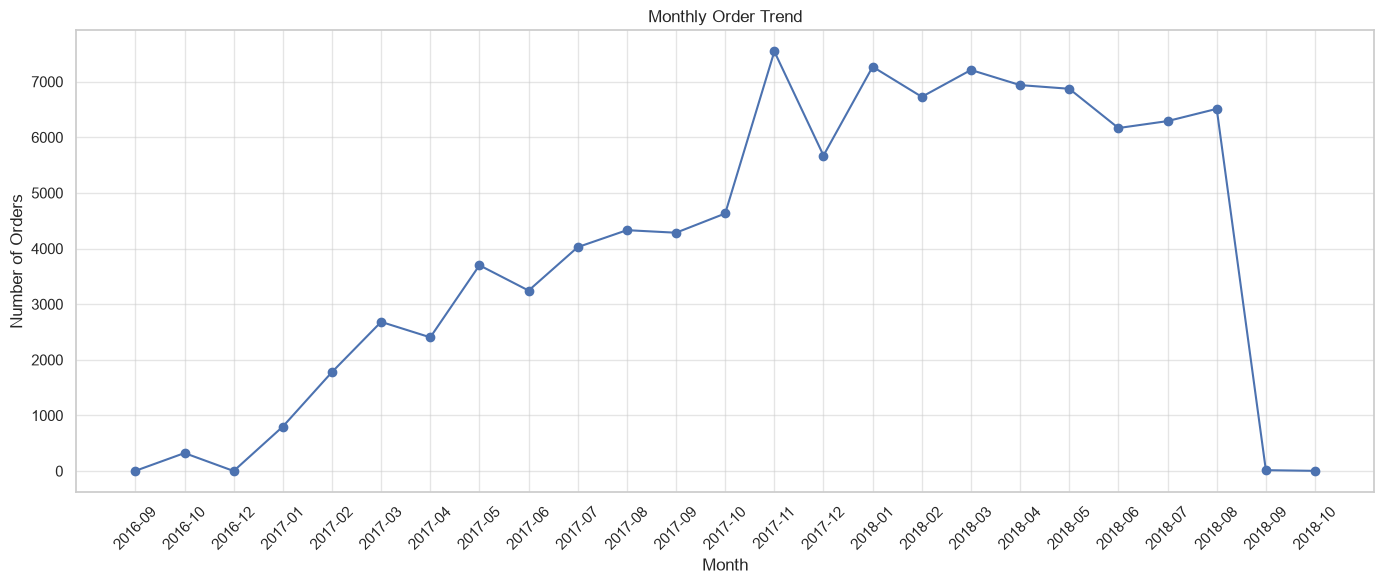

In [217]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Observations

The monthly order trend shows noticeable fluctuations throughout the observed period, together with an overall increase in order volume over time.

The unusually low activity observed near the beginning and end of the available time range should be interpreted cautiously because these periods may represent incomplete months in the dataset.

The observed variations suggest temporal changes in purchasing activity, although additional business context would be required to attribute these patterns to seasonality, promotional campaigns, or other external factors.

### 7.3 Order Delivery Time

Delivery time is an important performance indicator in e-commerce. This analysis measures the number of days between the purchase date and the customer's delivery date to evaluate delivery efficiency.

In [218]:
orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

In [219]:
orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

orders[
    ["order_purchase_timestamp",
     "order_delivered_customer_date",
     "delivery_time_days"]
].head()

,order_purchase_timestamp,order_delivered_customer_date,delivery_time_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0


In [220]:
orders["delivery_time_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time_days, dtype: float64

In [221]:
orders["delivery_time_days"].isna().sum()

np.int64(2965)

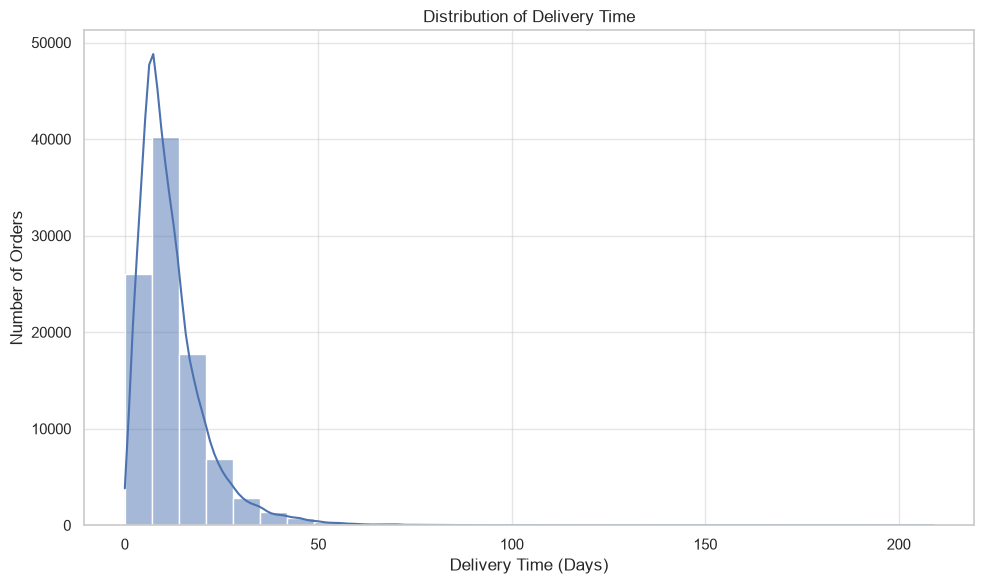

In [222]:
plt.figure(figsize=(10,6))

sns.histplot(
    orders["delivery_time_days"],
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

#### Observations

Most orders are delivered within a relatively short period, while a smaller number of orders require considerably longer delivery times.

The distribution is right-skewed, indicating that long delivery durations are uncommon but still present. Missing delivery times are primarily associated with orders whose delivery process was incomplete, including shipped, canceled, unavailable, or otherwise undelivered orders.

## 8. Business Insights

This section explores business-oriented insights derived from the Olist e-commerce dataset. The analyses focus on revenue generation, customer behavior, and factors that may influence customer satisfaction.

### 8.1 Payment Value by Payment Type

Different payment methods contribute differently to the overall payment volume. This analysis evaluates the total payment value processed by each payment type.

In [223]:
revenue_by_payment = (
    order_payments
    .groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_payment

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

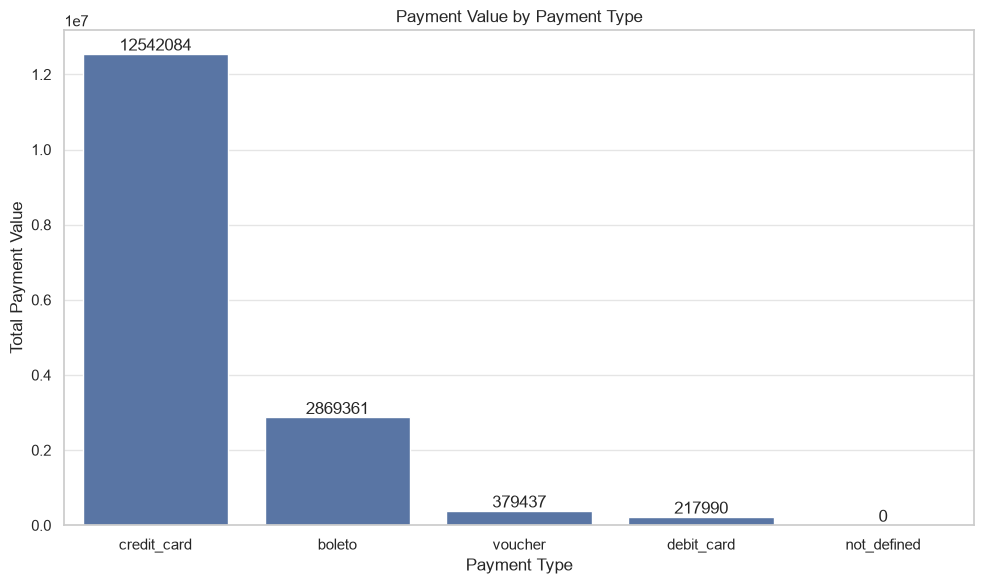

In [224]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=revenue_by_payment.index,
    y=revenue_by_payment.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Payment Value by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Total Payment Value")

plt.tight_layout()
plt.show()

### 8.2 Average Order Value by State

Average order value is analyzed across customer states to identify regional differences in purchasing behavior.

The calculation is performed at the order level by first aggregating item prices within each order and then computing the mean order value for each customer state.

In [225]:
order_values = (
    order_items
    .groupby("order_id", as_index=False)
    .agg(
        order_value=("price", "sum")
    )
)

customer_order_values = (
    orders[["order_id", "customer_id"]]
    .merge(
        customers[["customer_id", "customer_state"]],
        on="customer_id",
        how="inner"
    )
    .merge(
        order_values,
        on="order_id",
        how="inner"
    )
)

average_order_value_by_state = (
    customer_order_values
    .groupby("customer_state")["order_value"]
    .mean()
    .sort_values(ascending=False)
)

average_order_value_by_state.head(10)

customer_state
PB    216.669323
AP    198.151471
AC    197.320370
AL    195.413163
RO    186.804211
PA    184.482278
TO    177.855699
PI    176.296308
MT    173.259723
RN    172.271743
Name: order_value, dtype: float64

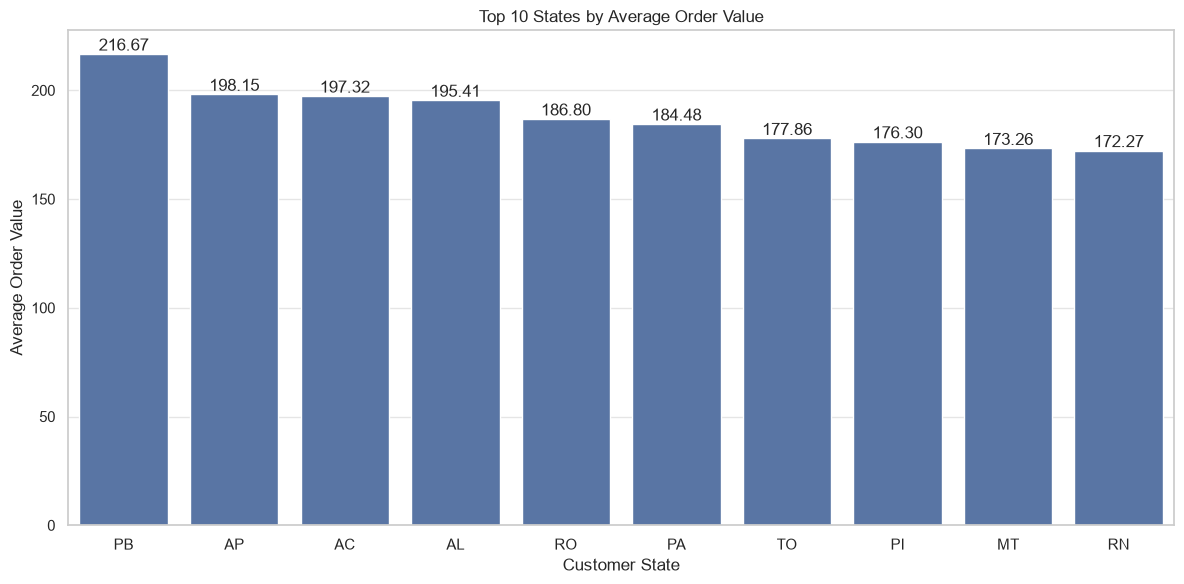

In [226]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=average_order_value_by_state.head(10).index,
    y=average_order_value_by_state.head(10).values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Top 10 States by Average Order Value")
plt.xlabel("Customer State")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.show()

#### Observations

The average order value differs across Brazilian states, suggesting regional differences in customer purchasing behavior.

States with higher average order values may represent markets where customers purchase more expensive products or larger quantities. These insights can support pricing strategies, regional marketing efforts, and inventory planning.

### 8.3 Review Score vs Delivery Time

Customer satisfaction may be influenced by delivery performance. This analysis investigates the relationship between delivery time and customer review scores to determine whether longer delivery times are associated with lower satisfaction levels.

In [227]:
delivery_reviews = orders.merge(
    order_reviews,
    on="order_id",
    how="inner"
)

delivery_reviews.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,delivery_time_days,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,2017-10,8.0,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,2018-07,13.0,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,2018-08,9.0,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,2017-11,13.0,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2018-02,2.0,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [228]:
delivery_by_review = (
    delivery_reviews
    .groupby("review_score")["delivery_time_days"]
    .mean()
    .reset_index()
)

delivery_by_review

,review_score,delivery_time_days
0,1,20.849825
1,2,16.194832
2,3,13.795278
3,4,11.848054
4,5,10.224097


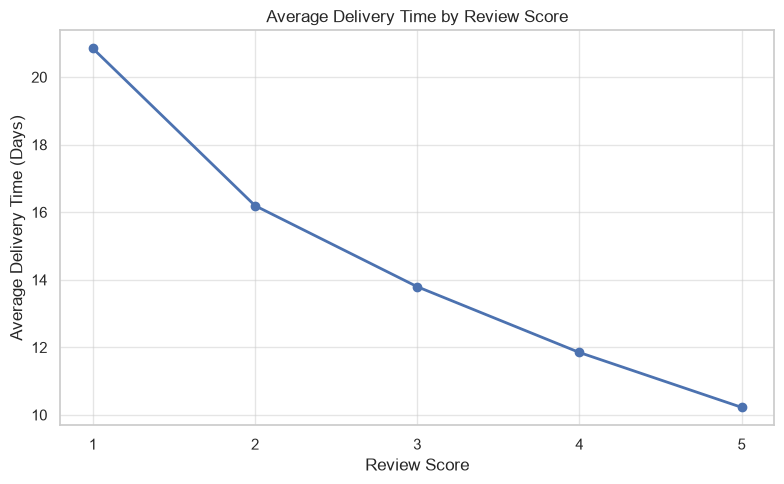

In [229]:
plt.figure(figsize=(8,5))

plt.plot(
    delivery_by_review["review_score"],
    delivery_by_review["delivery_time_days"],
    marker="o",
    linewidth=2
)

plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Time (Days)")

plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

In [230]:
delivery_reviews[
    ["delivery_time_days", "review_score"]
].corr()

,delivery_time_days,review_score
delivery_time_days,1.00000,-0.33366
review_score,-0.33366,1.00000


In [231]:
delivery_reviews["delivery_time_days"].corr(
    delivery_reviews["review_score"]
)

np.float64(-0.33366034110477144)

#### Observations

The analysis indicates an inverse relationship between delivery time and customer review scores. Orders with shorter delivery times generally receive higher ratings, while longer delivery times are associated with lower customer satisfaction.

The relationship is meaningful but not deterministic, suggesting that delivery performance is an important factor associated with customer satisfaction alongside other aspects of the customer experience.

## 9. Correlation Analysis

Correlation analysis is used to measure the strength and direction of relationships between numerical variables. A correlation heatmap provides a visual summary of these relationships and helps identify patterns that may be useful for feature engineering and machine learning.

### 9.1 Correlation Heatmap

This analysis examines the correlations among selected numerical features in the Olist dataset. Understanding these relationships can help identify influential variables and reduce redundancy before building machine learning models.

In [232]:
order_item_summary = (
    order_items
    .groupby("order_id", as_index=False)
    .agg(
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum")
    )
)

payment_summary = (
    order_payments
    .groupby("order_id", as_index=False)
    .agg(
        total_payment=("payment_value", "sum")
    )
)

correlation_data = (
    order_item_summary
    .merge(
        payment_summary,
        on="order_id",
        how="inner"
    )
    .merge(
        orders[["order_id", "delivery_time_days"]],
        on="order_id",
        how="left"
    )
)

correlation_data = correlation_data[
    [
        "total_price",
        "total_freight",
        "total_payment",
        "delivery_time_days"
    ]
].dropna()

correlation_data.head()

,total_price,total_freight,total_payment,delivery_time_days
0,58.90,13.29,72.19,7.0
1,239.90,19.93,259.83,16.0
2,199.00,17.87,216.87,7.0
3,12.99,12.79,25.78,6.0
4,199.90,18.14,218.04,25.0


In [233]:
correlation_matrix = correlation_data.corr()

correlation_matrix

,total_price,total_freight,total_payment,delivery_time_days
total_price,1.000000,0.411177,0.995935,0.055472
total_freight,0.411177,1.000000,0.491473,0.167124
total_payment,0.995935,0.491473,1.000000,0.069496
delivery_time_days,0.055472,0.167124,0.069496,1.000000


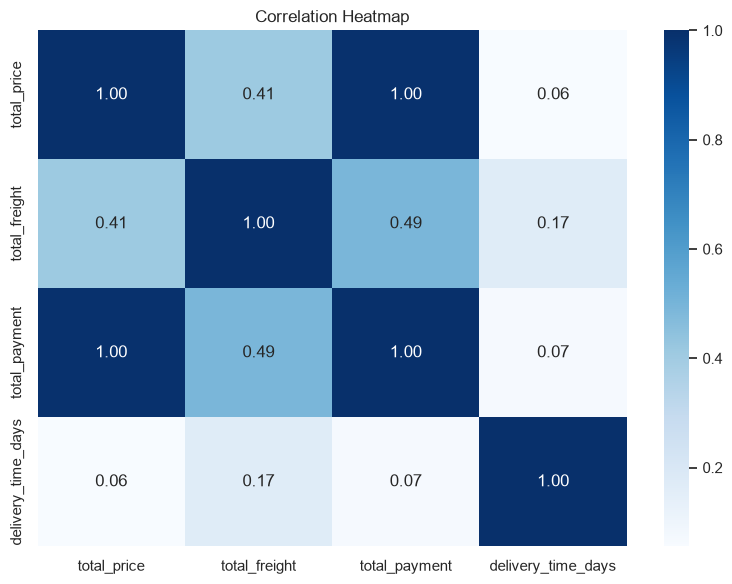

In [234]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

#### Observations

The correlation matrix reveals a very strong positive relationship between total product price and total payment value, which is expected because the final payment amount is largely determined by product prices together with freight charges.

Total freight shows a moderate positive relationship with total payment, while delivery time has only weak linear relationships with the monetary variables.

The near-perfect correlation between total price and total payment indicates potential redundancy. This relationship should be considered during feature selection to avoid including highly overlapping predictors in machine learning models.

# 10. Conclusion

This exploratory data analysis provided valuable insights into the Olist e-commerce dataset by examining customer behavior, order characteristics, payment methods, product categories, and delivery performance.

The main findings of the analysis include:

- Customer purchases are concentrated in a limited number of Brazilian states and cities.
- Credit cards are the dominant payment method and account for the highest total payment value.
- Product demand varies across categories, with several categories accounting for a significant portion of the marketplace.
- Delivery performance is meaningfully associated with customer satisfaction, as shorter delivery times are generally linked to higher review scores.
- Most numerical features exhibit weak to moderate correlations, while total price and total payment show a near-perfect positive relationship, indicating potential feature redundancy.

Overall, the exploratory analysis improved the understanding of the dataset, identified meaningful business insights, and revealed potential relationships among variables.

The next stage of the project will focus on feature engineering, where new predictive features will be created to support the development of machine learning models for customer intelligence and business analytics.